# Uncertainty and Stability Analysis

The goal of this notebook is to assess the reliability and stability of the logistic regression model fitted previously.

Rather than focusing on predictive performance, we quantify uncertainty in estimated effects to understand which conclusions are robust and which may be sensitive to sampling variability.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

In [6]:
df = pd.read_csv("data/heart_disease_uci.csv", index_col='id')
cl = df[df["dataset"] == "Cleveland"].copy()
cl = cl.dropna()
cl.shape

(297, 15)

In [9]:
cl["target"] = (cl["num"] >= 1).astype(int)

num_vars = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_vars = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

features = num_vars + cat_vars

X = cl[features]
y = cl["target"]

X = pd.get_dummies(X, columns = cat_vars, drop_first=True)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Next step, we attempt to test the reliability and stability of the regression coefficients using the Bootstrap method.

Point estimates of regression coefficients do not convey how stable those estimates are under sampling variability.

Bootstrap resampling provides an empirical approximation of the sampling distribution of coefficients, allowing us to assess uncertainty without strong parametric assumptions.

In [13]:
logit = LogisticRegression(
    solver = "liblinear",
    penalty = "l2",
    random_state=42
)

In [14]:
n = 1000
coef_samples = []
for i in range(n):
    x_bs, y_bs = resample(
        X_train_scaled,
        y_train,
        random_state = i
    )
    logit.fit(x_bs, y_bs)
    coef_samples.append(logit.coef_[0])

coef_samples = np.array(coef_samples)
coef_samples.shape

(1000, 17)

In [15]:
lower_ci = np.percentile(coef_samples, 2.5, axis = 0)
upper_ci = np.percentile(coef_samples, 97.5, axis = 0)
mean_coef = coef_samples.mean(axis = 0)

In [26]:
coef_bt = pd.DataFrame({
    "Feature": X_train.columns,
    "CI_Lower": lower_ci,
    "Mean_Coef": mean_coef,
    "CI_Upper": upper_ci
}).sort_values(by = "Mean_Coef", ascending = False)

coef_bt

,Feature,CI_Lower,Mean_Coef,CI_Upper
16,thal_reversable defect,-0.036926,0.705861,1.410491
4,oldpeak,0.049379,0.615126,1.227960
5,sex_Male,0.135359,0.591102,1.078412
1,trestbps,-0.106631,0.310425,0.754205
0,age,-0.148909,0.283959,0.692201
2,chol,-0.180421,0.274892,0.863488
13,slope_flat,-0.369410,0.220589,0.800899
12,exang_True,-0.200993,0.206544,0.618215
9,fbs_True,-0.369636,0.031836,0.407183
11,restecg_st-t abnormality,-0.316661,0.012607,0.319902


In [37]:

stable = coef_bt[
    (coef_bt["CI_Lower"] > 0) | (coef_bt["CI_Upper"] < 0)
]
stable.style.hide(axis='index')


Feature,CI_Lower,Mean_Coef,CI_Upper
oldpeak,0.049379,0.615126,1.227960
sex_Male,0.135359,0.591102,1.078412
cp_atypical angina,-0.921205,-0.479573,-0.068821
cp_typical angina,-1.002656,-0.518996,-0.088312
cp_non-anginal,-1.487819,-0.980307,-0.528397


In [38]:
unstable = coef_bt[
    (coef_bt["CI_Lower"] <= 0) & (coef_bt["CI_Upper"] >= 0)]
unstable.style.hide(axis='index')

Feature,CI_Lower,Mean_Coef,CI_Upper
thal_reversable defect,-0.036926,0.705861,1.410491
trestbps,-0.106631,0.310425,0.754205
age,-0.148909,0.283959,0.692201
chol,-0.180421,0.274892,0.863488
slope_flat,-0.369410,0.220589,0.800899
exang_True,-0.200993,0.206544,0.618215
fbs_True,-0.369636,0.031836,0.407183
restecg_st-t abnormality,-0.316661,0.012607,0.319902
thal_normal,-0.923912,-0.181291,0.502472
slope_upsloping,-0.861916,-0.214055,0.481896


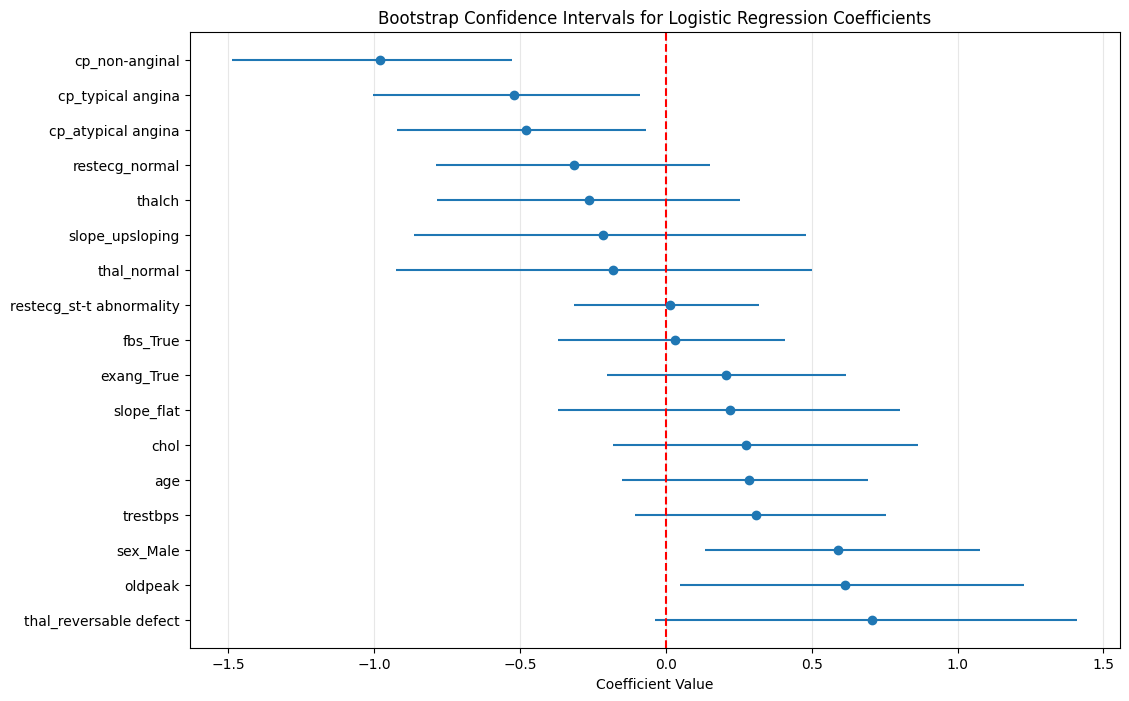

In [30]:

plt.figure(figsize=(12, 8))


plt.errorbar(
    coef_bt["Mean_Coef"],
    coef_bt["Feature"],
    xerr=[
        coef_bt["Mean_Coef"] - coef_bt["CI_Lower"],
        coef_bt["CI_Upper"] - coef_bt["Mean_Coef"]
    ],
    fmt="o"
)


plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap Confidence Intervals for Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.grid(axis = 'x', alpha = 0.3)
plt.show()


Uncertainty analysis highlights that not all statistically estimated effects are equally reliable.

In this study, stability is defined in terms of directional consistency under resampling. Bootstrap approximates the sampling distribution of coefficients. If confidence intervals exclude zero, this indicates a robust directional effect, called Robust Predictors; otherwise, it indicates responsiveness to sampling variability, which should not be over-interpreted, so-called Unstable Variables.

Among robust predictors, two categories can be distinguished. Predictors with both lower and upper confidence interval bounds above zero are classified as risk factors, whereas predictors with both bounds below zero are classified as protective factors. In this case, *oldpeak* and *sex* act as risk factors, while *cp_atypical angina*, *cp_typical angina*, and *cp_non-anginal* function as protective factors relative to the reference category.

In a clinical risk assessment context, model-driven decisions should treat unstable variables with particular caution, as their estimated effects are highly sensitive to sampling variation.


### Summary of Uncertainty Analysis

This analysis demonstrates that while logistic regression provides interpretable risk estimates, not all coefficient estimates are equally stable.

Bootstrap-based uncertainty assessment reveals which predictors support robust conclusions and which require cautious interpretation.

Such analysis is essential for reliable and responsible use of statistical models in high-stakes decision settings.